# 

# 12. Crop Management

Crop management BMPs specifies the crop rotation, fertilizer
application, tillage and gazing on a field. As this data is highly
customized, it’s usually prepared manually and imported to bmp database.

AAFC crop inventory provides crop distribution each year based on remote
sensing technology. Combined with default crop rotation, fertilizer
application, tillage and gazing fro crop type, it’s possible to setup
the crop management BMPs automatically. To use this feature, setup the
crop_rotation section in the model configuration file in crop_rotation
section. The setting items are given below.

-   **method** - the only option now is crop_inventory.

-   **AAFC_crop_inventory_folder** - the folder the crop inventory
    GeoTIFF files reside. The file name must be the year, e.g. 2025.tif.

-   **first_year** - the starting year of inventory data to read.

-   **last_year** - the ending year of inventory data to read.

-   **include_grazing** - the flag for grazing generation. By default
    it’s false.

One example is given below.

    [crop_rotation]
    method = crop_inventory
    AAFC_crop_inventory_folder = C:\Work\Git\imWEBs\imWEBs-Python\notebooks\stc\data\crop_inventory 
    first_year = 1991
    last_year = 2010
    include_grazing = False

Users will need to download the crop inventory data for the years they
are interested and clipped to the watershed boundary. It’s also required
to have same coordination system as other input files.

## Workflow

The workflow is described below.

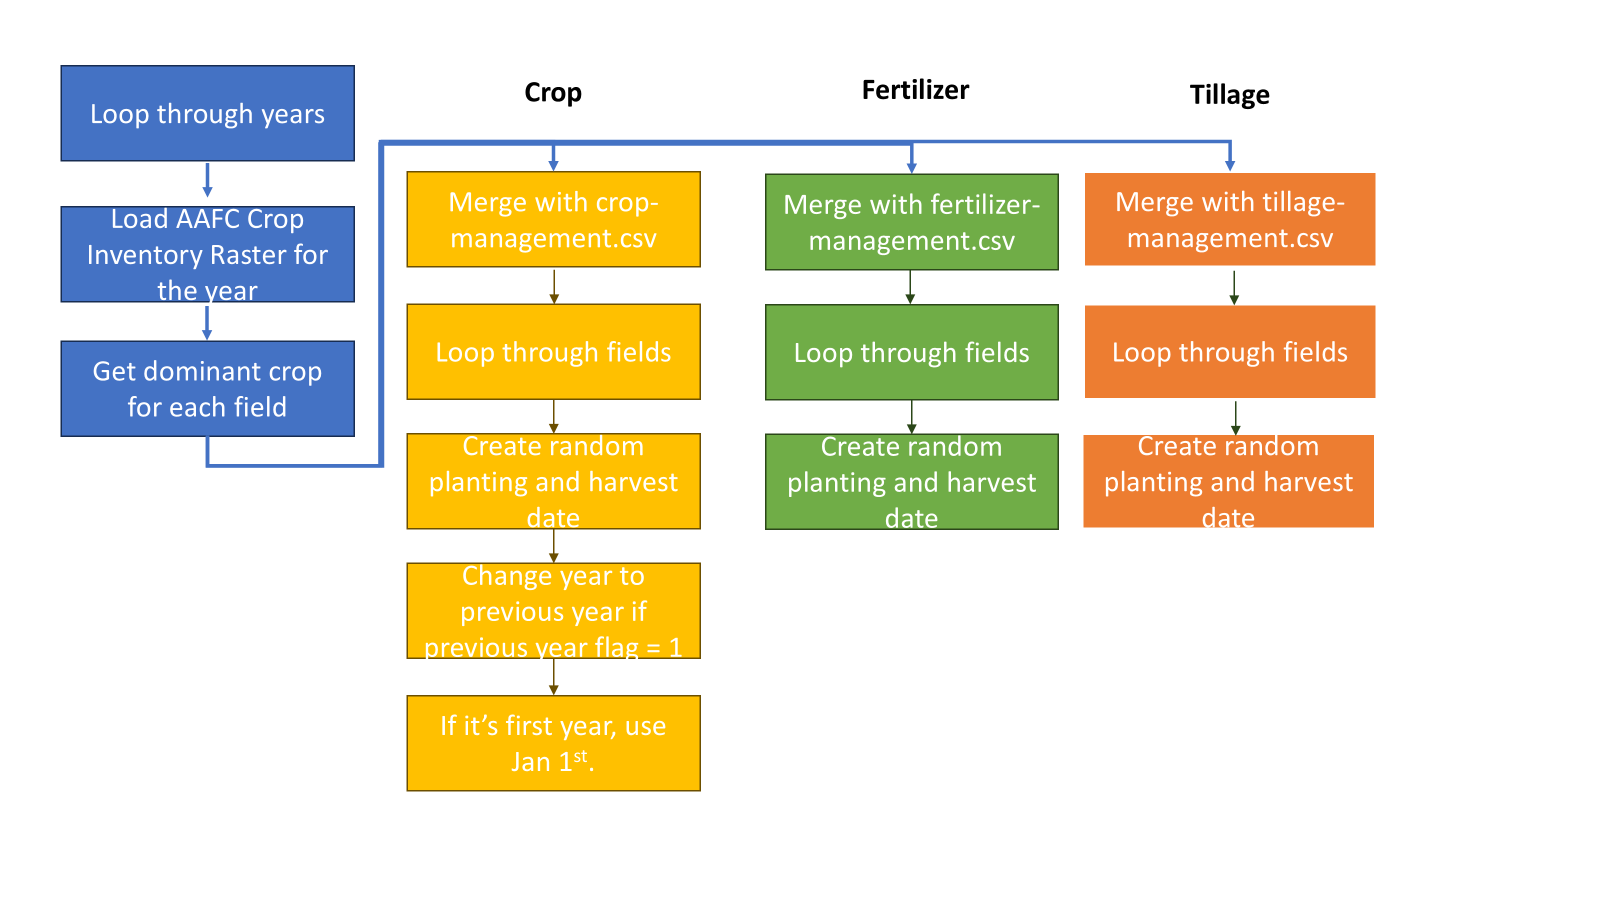

## User-defined crop lookup table and default management data for crop, fertilizer and tillage

The system has default crop lookup table and default management data for
crop, fertilizer and tillage. If users wants to use their own data, they
could have these files in **AAFC_crop_inventory_folder** with the
following file name. These files must follow the standard formats as
given below.

-   **crop-lookup.csv**

    | Original ID | Land use name | Group    | IMWEBs code | IMWEBs ID   |
    |-------------|---------------|----------|-------------|-------------|
    | 10          | Cloud         | Non-Crop |             | Not proceed |

-   **crop-management.csv**

    | CropCode | Pervious Year | PlantingMon_First | PlantingDay_First | PlantingMon_Last | PlantingDay_Last | HarvestMon_First | HarvestDay_First | HarvestMon_Last | HarvestDay_Last | HarvestEfficiency | HarvestType | HarvestIndexOverride | CNOP | StoverFraction | IsGrain | PRCOP |
    |-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
    | 1 | 0 | 5 | 8 | 5 | 21 | 9 | 24 | 10 | 7 | 0.85 | 2 | 0 | 1 | 0 | 1 | 1 |

-   **fertilizer-management.csv**

    | CropCode | FerMon_First | FerDay_First | FerMon_Last | FerDay_Last | FerType | FerRate | FerSurface |
    |---------|---------|---------|---------|---------|---------|---------|---------|
    | 1 | -1000 | -1000 | -1000 | -1000 | 1 | 70 | 0.2 |

-   **tillage-management.csv**

    | CropCode | TillMon_First | TillDay_First | TillMon_Last | TillDay_Last | TillCode |
    |------------|------------|------------|------------|------------|------------|
    | 1        | -1000         | -1000         | -1000        | -1000        | 35       |
    | 1        | -70           | -70           | -70          | -70          | 86       |

## Random Date

To simulate the behavior of farmers, plating, harvest, fertilizer and
tillage dates could be generate randomly between a starting and ending
day defined in the table. In each table, the starting and ending
month/day is defined. This is only applied when month and day value is
valid month and day values.

## Negative Month and Day

The month and day could be negative for fertilizer and tillage. It’s
illustrated in the following diagram. In this case, all four month/day
column should have the same value.

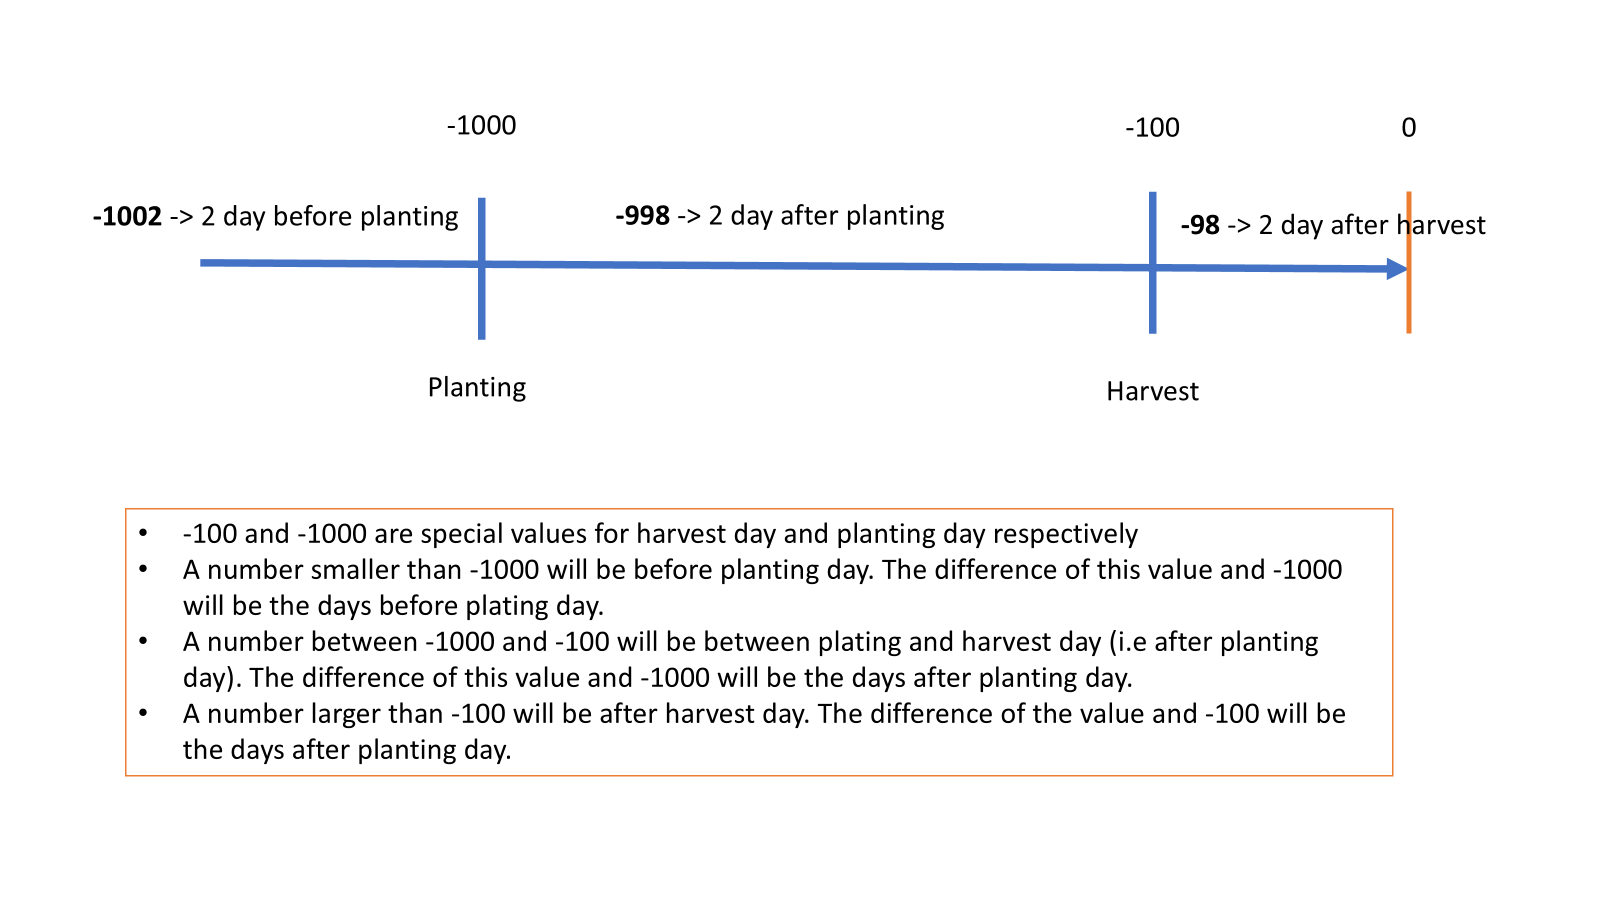

## Winter Wheat

If the previous year column is 1 in crop_management.csv, the system
assumes it’s planted in previous year. For example, if the dominant crop
in a field is winter wheat in 2000, the year in crop_management table
will be 1999. The imWEBs engine will see it planted in 1999 and
harvested in 2000.